I will be using the pandas library to analyze the data. 

Note: I don't have any prior experience with pandas, so I asked ChatGPT to teach me the syntax and debug the code whenever I ran into syntax errors.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Traffic.csv')

I will first tackle the question: Which features are most strongly associated with high or low traffic volumes?

Let's first try to visualize the data to make some hypotheses.
Below are two bar graphs. In both graphs, the verticle axis represents the median number of vehicles present across the entire data set. The first bar graph examines the day of the week, and the second bar graph examines the time of the day.



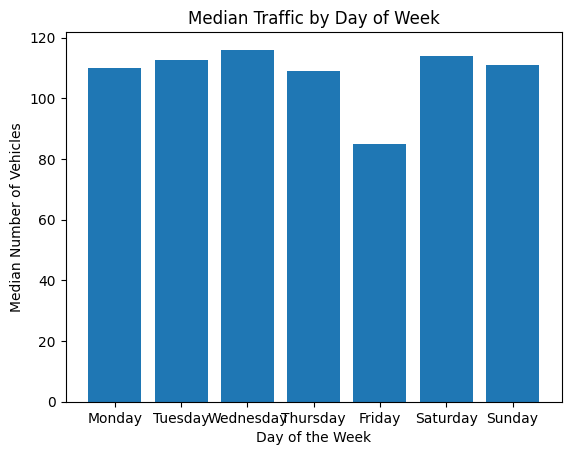

In [8]:
day_of_week = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# day_of_week_med refers to the median number of vehicles per day of the week
day_of_week_med = []
for day in day_of_week:
    dataset = df[(df['Day of the week'] == day)]
    day_of_week_med.append(dataset["Total"].median())

# creates bar graph
day = np.array(day_of_week)
median = np.array(day_of_week_med)

plt.bar(day, median)
plt.xlabel("Day of the Week")
plt.ylabel("Median Number of Vehicles")
plt.title("Median Traffic by Day of Week")

plt.show()



For the Friday hypothesis, I attempted to calculate the phi coefficient between the following two binary variables:
- Whether or not it is a Friday
- Whether or not traffic is heavy

However the coefficient was only about 0.019, which doesn't suggest a strong correlation. 

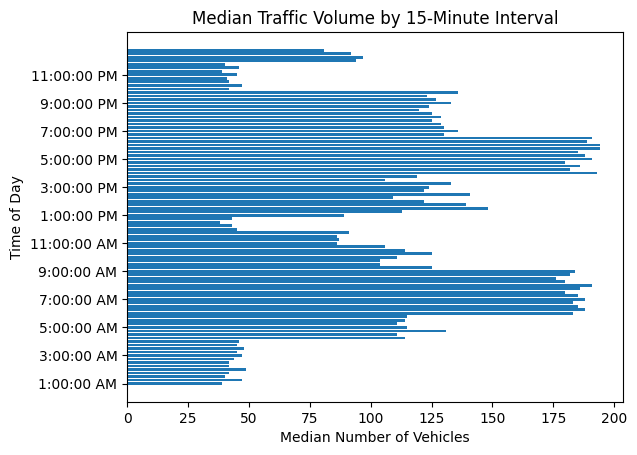

In [12]:
time_am = []
time_pm = []

for hr in range(1,13):
    for min in range(0,46,15):
        if min == 0:
            str_min = "00"
        else:
            str_min = str(min)
        time_am.append(str(hr) + ":" + str_min + ":00 AM")
        time_pm.append(str(hr) + ":" + str_min + ":00 PM")

time_list = time_am+time_pm

# time_med refers to the median number of vehicles per 15-min interval
time_med = []
for time in time_list:
    dataset = df[(df['Time'] == time)]
    time_med.append(dataset["Total"].median())


# creates bar graph
time_axis = np.array(time_list)
median = np.array(time_med)
plt.barh(time_axis,median)
plt.yticks(ticks=[8*i for i in range(12)])
plt.xlabel("Median Number of Vehicles")
plt.ylabel("Time of Day")
plt.title("Median Traffic Volume by 15-Minute Interval")

plt.show()



From the graphs, I can make the following hypotheses:
- There is less traffic on Fridays.
- Rush hours are 6AM-10AM and 4PM-7PM.

For the rush hours, I wanted to use pandas's corr() method to find the strength of the correlation. I suspect that the closer a data point is to the nearest rush hour, the more vehicles there will be in total.

To put this more concretely, I want to create a new column which calculates the difference, in minutes, between the current time and nearest rush hour. 

In [ ]:
# I plan to use the datetime library in Python to convert the 'time' 
# column into time objects, which I can then use to calculate the time
# difference to put on the new column. 

Once I have the new column, I will use the corr() method to find the Pearson correlation coefficient. If the relationship is not linear, then I will find the Spearman's rank correlation coefficient instead. Hopefully, this will show a strong correlation between the time of day and level of traffic. 

In [ ]:
# display correlation coefficients here

I would also like to examine whether some vehicles influence traffic more than others. To do that, I would graph a scatterplot with two variables:
- Number of specfic type of vehicle
- Whether or not the traffic was heavy (not heavy = 0, heavy = 1)
With one (almost) continuous variable and one binary variable, I will use point-biserial correlation coefficient to examine which vehicles have the most influence over traffic. I suspect bikes have the least influence on traffic and buses have the most, but I won't know for sure until I do the statistical test. 

For the question "How are the different features correlated with each other?", we can run similar statistical tests to find correlations. For example, buses will likely be correlated with specific times as they are on a schedule. 

I will now explain my thought process for the question "Can you predict traffic conditions for the next 15-30 minutes?".

I plan on using the first 2 weeks of the data for training the models, and the last 2 weeks for testing its accuracy. Here are the parameters I will use to predict traffic:
- Number of minutes away from nearest rush hour (most major factor)
- Number of vehicles seen most recently (major factor)
- Number of each type of vehicle present (minor factor)
- If it is Friday (minor factor)

- Linear regression: This model will assume a linear correlation between each parameter and the traffic conditions. Since we are using multiple parameters, the equation will be a hyperplane of best fit. We will use that equation to predict traffic conditions. 
- Random forest: I will implement this using the sklearn library. I plan on manually tuning the number of trees, tree depth, and minimum samples needed to split a node. 

Now for the last question: "How does the prediction accuracy change when you increase or decrease the forecasting window? Does this effect vary by model?"

The prediction accuracy will go down as the forecasting window increases, but the degree it will decrease varies by model. Generally, the linear regression will be a less accurate model than the random forest algorithm. In reality the relationships between the parameters and traffic conditions would not be linear, and the random forest algorithm accounts for that while linear regression does not.